# Construct an LDPC Code and Encode a Codeword

This code is provided as supplementary material of the lecture Channel Coding - Graph-based Codes.

This code illustrates
* Construct an irregular LDPC code according to a predefined degree distribution
* Rearranging the parity-check matrix of an LDPC code according to the method provided in T. Richardson, R. Urbanke, "Efficient encoding of low density parity check codes," _IEEE Transactions on Information Theory_, vol. 47, no. 2, Feb. 2001
* Illustrate encoding by means of an example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.append('../ch5_LDPC_Finite_Length/')
from ipynb.fs.defs.getIrregularH import getIrregularH, node_to_edge
from ipynb.fs.defs.Encode_LDPC import Encode_LDPC

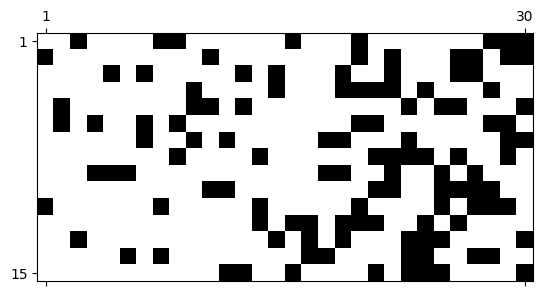

[[0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]]


In [3]:
# construct an irregular matrix
# degree distribtion
# variables node of degrees 2 3 and 6. nodes_dv contains the factors
# Lambda_i, i.e., we have 6 variable nodes of degree 2, 12 variable nodes
# of degree 3 and 12 variable nodes of degree 6
rng = np.random.default_rng()

dv = np.array([2, 3, 6])
nodes_dv = np.array([6, 12, 12])

# 15 check nodes of degree 8
dc = 8
nodes_dc = np.array([15])

# normalize degree distribution
nodes_dv_norm = nodes_dv / np.sum(nodes_dv)
nodes_dc_norm = nodes_dc / np.sum(nodes_dc)

# get polynomials lambda and rho
lambdA = node_to_edge(dv, nodes_dv_norm)
rho = node_to_edge(dc, nodes_dc_norm)

H = getIrregularH(sum(nodes_dv), lambdA, rho)
plt.spy(H)
m, n = H.shape
plt.xticks([0, n-1], [1, n])
plt.yticks([0, m-1], [1, m])
plt.show()

# generate random information word
u = rng.integers(2, size=(1, 15)) - 1

# uses a slightly different representation using an upper triangular matrix
# T than in the lecture. Conceptually identical though
x = Encode_LDPC(H, u)

# verify that x is a codeword
print(np.mod(H*x,2))